Every imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,r2_score
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

Loadind dataset

In [3]:
df=pd.read_csv("Student_Performance.csv")
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


Label Encoder

In [4]:
genderdf=df[['student_id','gender']]
genderdf.head()
le=LabelEncoder()
genderdf['genderEncoder']=le.fit_transform(genderdf['gender'])
print(genderdf.head())

schooldf=df[['student_id','school_type']]
schooldf['schoolEncoder']=le.fit_transform(schooldf['school_type'])
print(schooldf.head())

   student_id  gender  genderEncoder
0           1    male              1
1           2  female              0
2           3  female              0
3           4   other              2
4           5  female              0
   student_id school_type  schoolEncoder
0           1      public              1
1           2      public              1
2           3     private              0
3           4      public              1
4           5      public              1


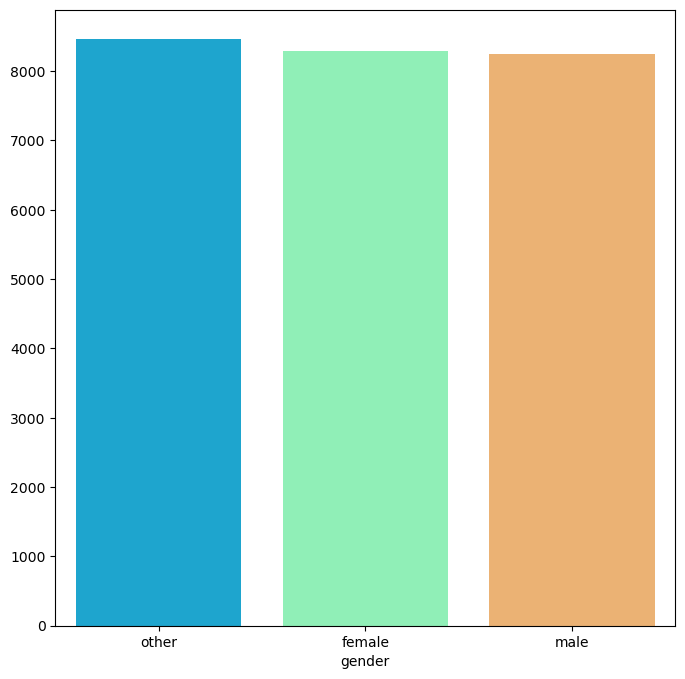

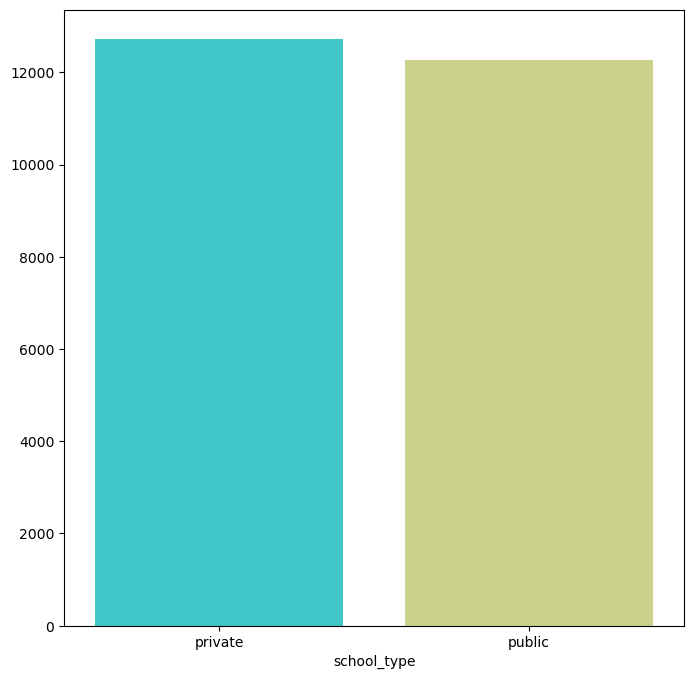

In [5]:
genderCount=df['gender'].value_counts()
plt.figure(figsize=(8,8))
sns.barplot(x=genderCount.index,y=genderCount.values,palette='rainbow')
plt.show()

schoolCount=df['school_type'].value_counts()
plt.figure(figsize=(8,8))
sns.barplot(x=schoolCount.index,y=schoolCount.values,palette='rainbow')
plt.show()

One-hot Encoder

In [6]:
dfEncoded=pd.get_dummies(df['parent_education'])
dfEncoded.head()

,diploma,graduate,high school,no formal,phd,post graduate
0,False,False,False,False,False,True
1,False,True,False,False,False,False
2,False,False,False,False,False,True
3,False,False,True,False,False,False
4,False,False,True,False,False,False


StandardScaler and MinMaxsclar

In [7]:
modeldf=df[['study_hours','overall_score']]
standardscaler=StandardScaler()
standardscaled=standardscaler.fit_transform(modeldf)
print(pd.DataFrame(standardscaled,columns=['study_hours','overall_score']).head())

minmaxsclar=MinMaxScaler()
minmaxsclaed=minmaxsclar.fit_transform(modeldf)
print(pd.DataFrame(minmaxsclaed,columns=['study_hours','overall_score']).head())

   study_hours  overall_score
0    -0.532053      -0.576082
1    -0.255236      -0.142944
2     1.682482       1.351907
3    -1.454776      -1.183530
4    -1.362504      -2.039240
   study_hours  overall_score
0     0.346667       0.451462
1     0.426667       0.547368
2     0.986667       0.878363
3     0.080000       0.316959
4     0.106667       0.127485


Train and testing split

In [44]:
X=df[['study_hours']].head(10)
y=df[['overall_score']].head(10)

XTrain,XTest,yTrain,yTest=train_test_split(X,y,test_size=0.3,random_state=42)

print(f"Train data: {XTest}        {yTrain}")
print(f"Test data: {XTest}         {yTest}")

Train data:    study_hours
8          3.2
1          3.7
5          3.8           overall_score
0           53.1
7           69.6
2           89.6
9           69.6
4           25.4
3           41.6
6           39.1
Test data:    study_hours
8          3.2
1          3.7
5          3.8            overall_score
8           55.2
1           61.3
5           63.5


Linear regression

In [ ]:
modeldf=df[['study_hours','overall_score']].head(10)
model=LinearRegression()
X=modeldf[['study_hours']]
y=modeldf['overall_score']

model.fit(X,y)
predictedScore=model.predict(X)


hours=int(input("How many hours have you studied: "))
result=model.predict([[hours]])
print(f"Based on yours hours: {hours} you may score around {result.round(2)}")

mae=mean_absolute_error(y,predictedScore)
mse=mean_squared_error(y,predictedScore)
rmse=np.sqrt(mse)
r2=r2_score(y,predictedScore)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE {rmse}")
print(f"R^2: {r2}")


Based on yours hours: 7 you may score around [80.45]
MAE: 4.9685980481018515
MSE: 37.428430260744925
RMSE 6.117877921366601
R^2: 0.8758675037783731


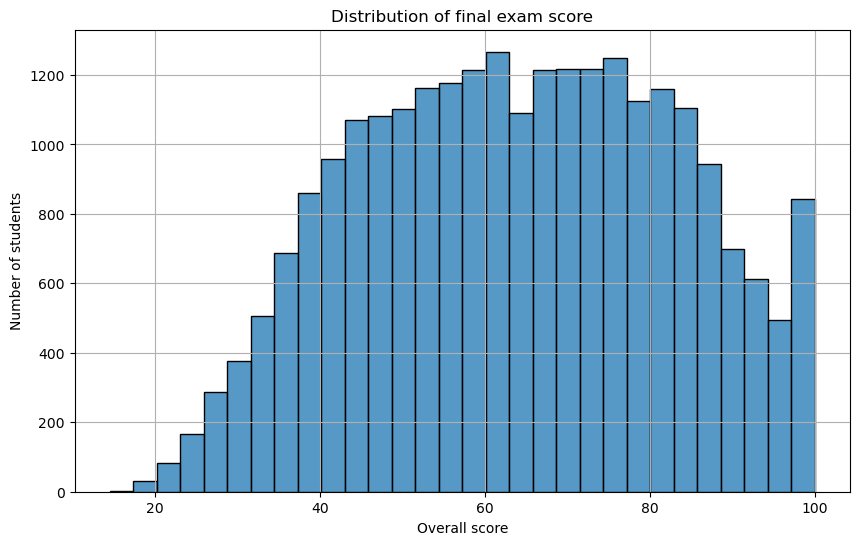

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['overall_score'],bins=30,palette='rainbow')
plt.title("Distribution of final exam score")
plt.xlabel("Overall score")
plt.ylabel("Number of students")
plt.grid(True)
plt.show()

Scatter + Regrssion line

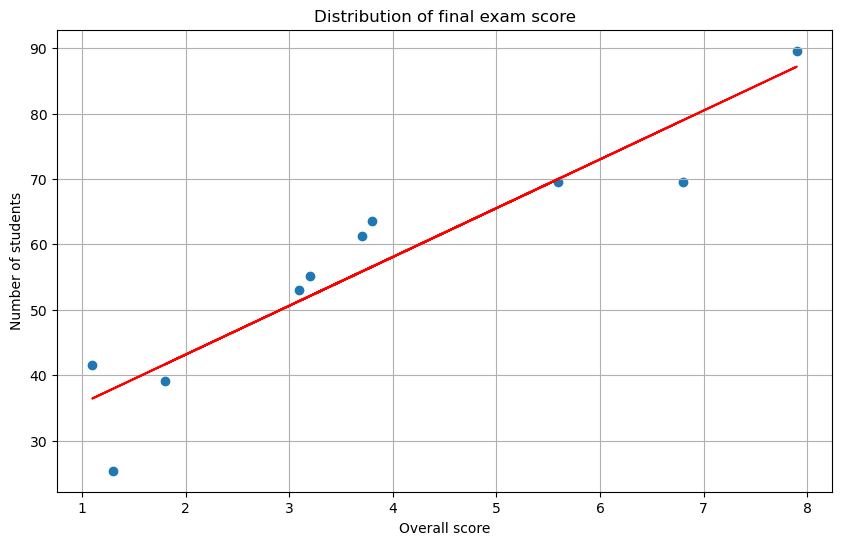

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(X,y,label="Actual Scores")
plt.title("Distribution of final exam score")
plt.plot(X,predictedScore,label="Predicted Score (Regression line)",color="red")
plt.xlabel("Overall score")
plt.ylabel("Number of students")
plt.grid(True)
plt.show()

Logistis regression

In [38]:
modeldf=df[['study_hours','overall_score']]
X=modeldf[['study_hours']]
y=((df['study_hours']>=3)).astype(float)

model=LogisticRegression()
model.fit(X,y)
hours=int(input("Enter hours: "))
result=model.predict([[hours]])[0]
prediction1=model.predict(X)

if result==1:
    print(f"Based on your hours: {hours} you may be PASS")
else:
    print(f"Based on your hours: {hours} you may be Fail")

cm=confusion_matrix(y,prediction1)
print(cm)
precisison=precision_score(y,prediction1)
accuracy=accuracy_score(y,prediction1)
recall=recall_score(y,prediction1)
f1=f1_score(y,prediction1)

print(f"Accuary: {accuracy}")
print(f"precision: {precisison}")
print(f"Recall: {recall}")
print(f"f1: {f1}")


Based on your hours: 4 you may be PASS
[[ 8093     0]
 [    0 16907]]
Accuary: 1.0
precision: 1.0
Recall: 1.0
f1: 1.0


In [40]:
modeldf=df[['study_hours','overall_score']]
X=modeldf[['overall_score']]
y=((modeldf['overall_score'] >=40)).astype(float)

model=LogisticRegression()
model.fit(X,y)
marks=int(input("Enter your marks: "))
result=model.predict([[marks]])[0]
prediction2=model.predict(X)


if result==1:
    print(f"Based on your marks: {marks} you may be PASS")
else:
    print(f"Based on your marks: {marks} you may be Fail")


Based on your marks: 39 you may be Fail


K-Nearest Neighbors(KNN)

In [35]:
modeldf=df[['math_score','science_score','english_score']]
X=modeldf
y=((df['math_score'] >=40) & (df['science_score'] >=40) & (df['english_score'] >=40)).astype(int)

XTrain,XTest,YTrain,yTest=train_test_split(X,y,test_size=0.2,random_state=42)

model=KNeighborsClassifier(n_neighbors=3)
model.fit(XTrain,YTrain)

mathScore=int(input("enter math marks"))
englishScore=int(input("enter english marks"))
scienceScore=int(input("enter science marks"))
result=model.predict([[mathScore,scienceScore,englishScore]])[0]
predictions = model.predict(XTest)

if result==1:
    print("Based on your marks you may PASS")
else:
    print("Based on your marks you may FAIL")
print("Accuracy:", accuracy_score(yTest, predictions))


Based on your marks you may PASS
Accuracy: 0.9906


Decision Tree 

In [43]:
X=df[['math_score','science_score','english_score']]
y=((df['math_score'] >=40) & (df['science_score'] >=40) & (df['english_score'] >=40)).astype(int)

XTrain,XTest,yTrain,yTest=train_test_split(X,y,test_size=0.3,random_state=42)

model=DecisionTreeClassifier()
model.fit(XTrain,yTrain)

mathScore=int(input("enter math marks"))
englishScore=int(input("enter english marks"))
scienceScore=int(input("enter science marks"))
result=model.predict([[mathScore,scienceScore,englishScore]])[0]
predictions = model.predict(XTest)

if result==1:
    print("Based on your marks you may PASS")
else:
    print("Based on your marks you may FAIL")

accuracy=accuracy_score(yTest,predictions)
print(f"Accuracy: {accuracy}")


Based on your marks you may FAIL
Accuracy: 0.9998666666666667


In [15]:
modeldf

,math_score,science_score,english_score
0,42.7,55.4,57.0
1,57.6,68.8,64.8
2,84.8,95.0,79.2
3,44.4,27.5,54.7
4,8.9,32.7,30.0
5,51.5,78.3,63.9
6,41.9,29.4,39.2
7,56.7,60.1,53.4
8,54.1,59.5,38.3
9,71.9,70.4,81.3


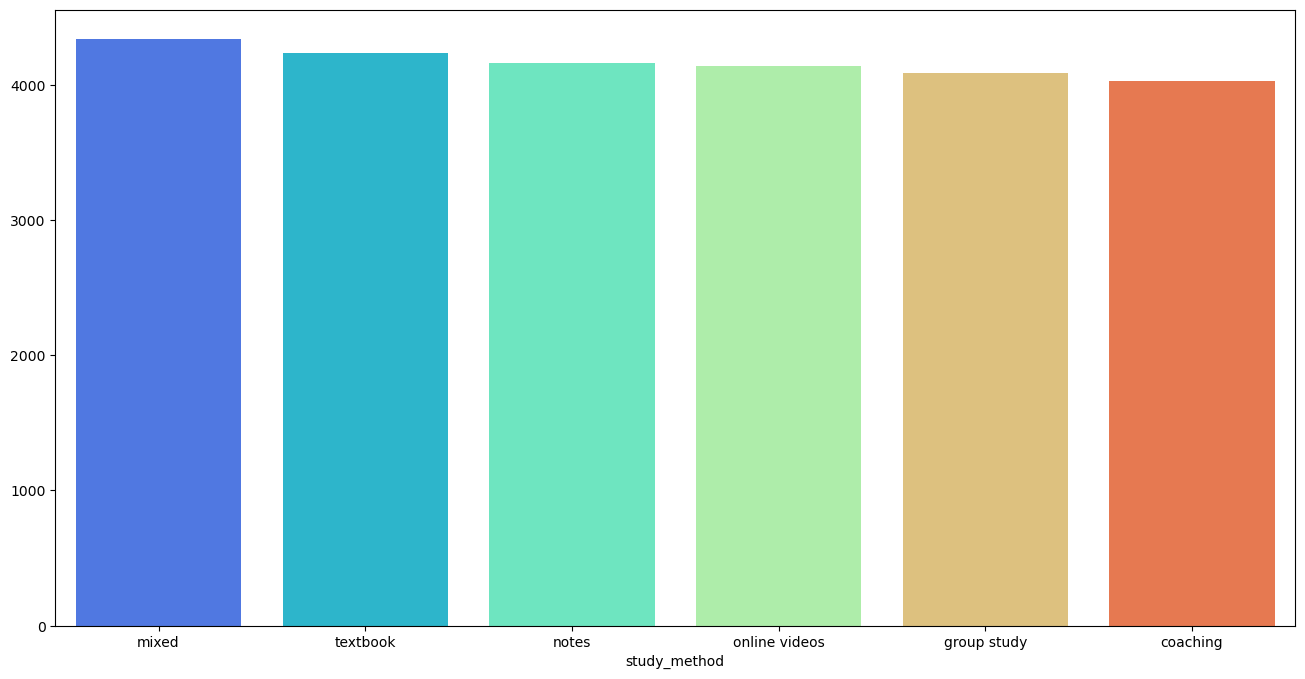

In [16]:
methodsCount=df['study_method'].value_counts()
plt.figure(figsize=(16,8))
sns.barplot(x=methodsCount.index,y=methodsCount.values,palette="rainbow")
plt.show()

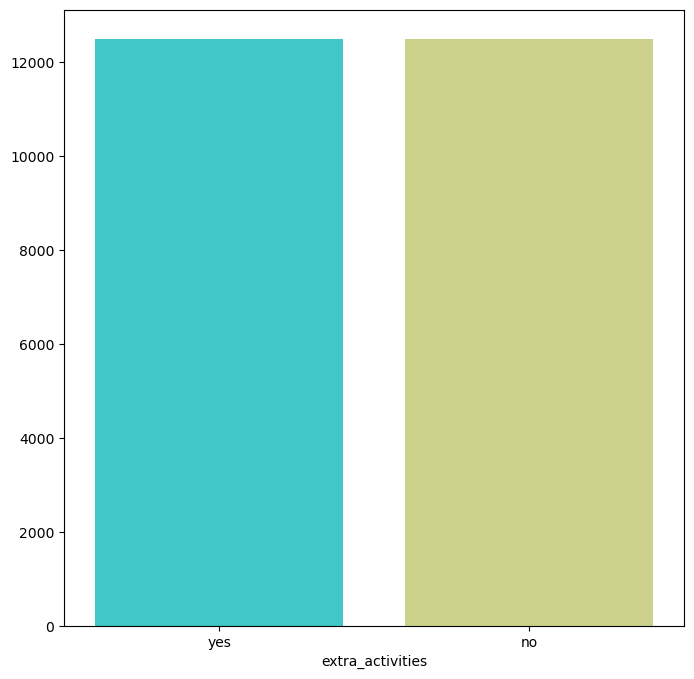

In [17]:
extraActivitiesCount=df['extra_activities'].value_counts()
plt.figure(figsize=(8,8))
sns.barplot(x=extraActivitiesCount.index,y=extraActivitiesCount.values,palette='rainbow')
plt.show()

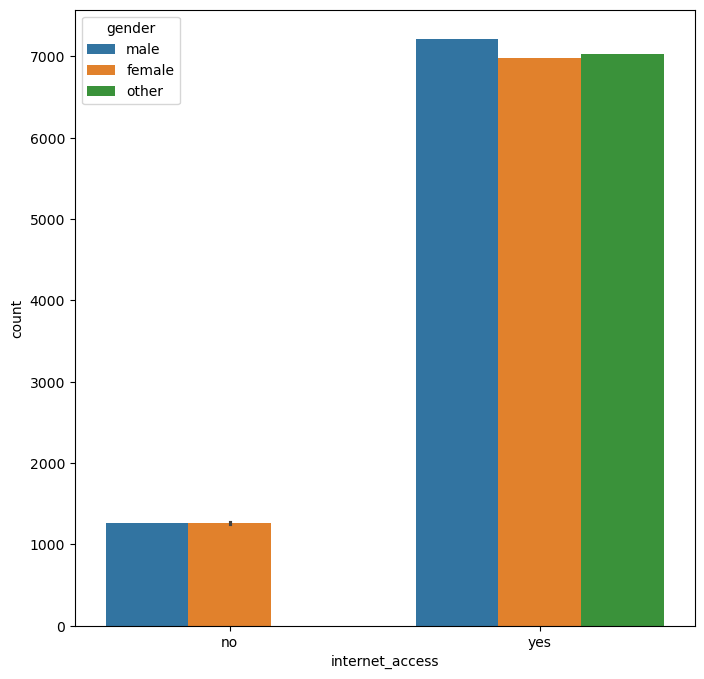

In [18]:
data=df.groupby(['internet_access','gender']).size().reset_index(name='count')
plt.figure(figsize=(8,8))
sns.barplot(x=data['internet_access'],y=data['count'],hue=df['gender'])
plt.show()

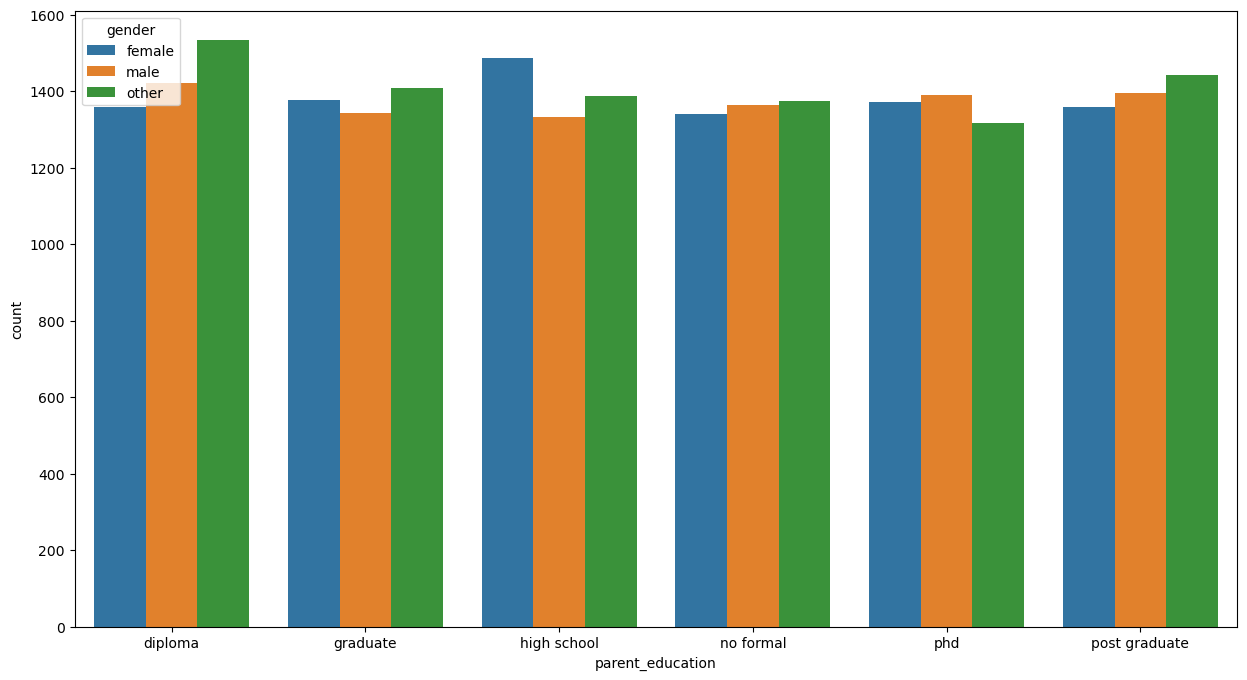

In [19]:
data=df.groupby(['parent_education','gender']).size().reset_index(name='count')
plt.figure(figsize=(15,8))
sns.barplot(data=data,x='parent_education',y='count',hue='gender')
plt.show()

<Axes: xlabel='final_grade'>

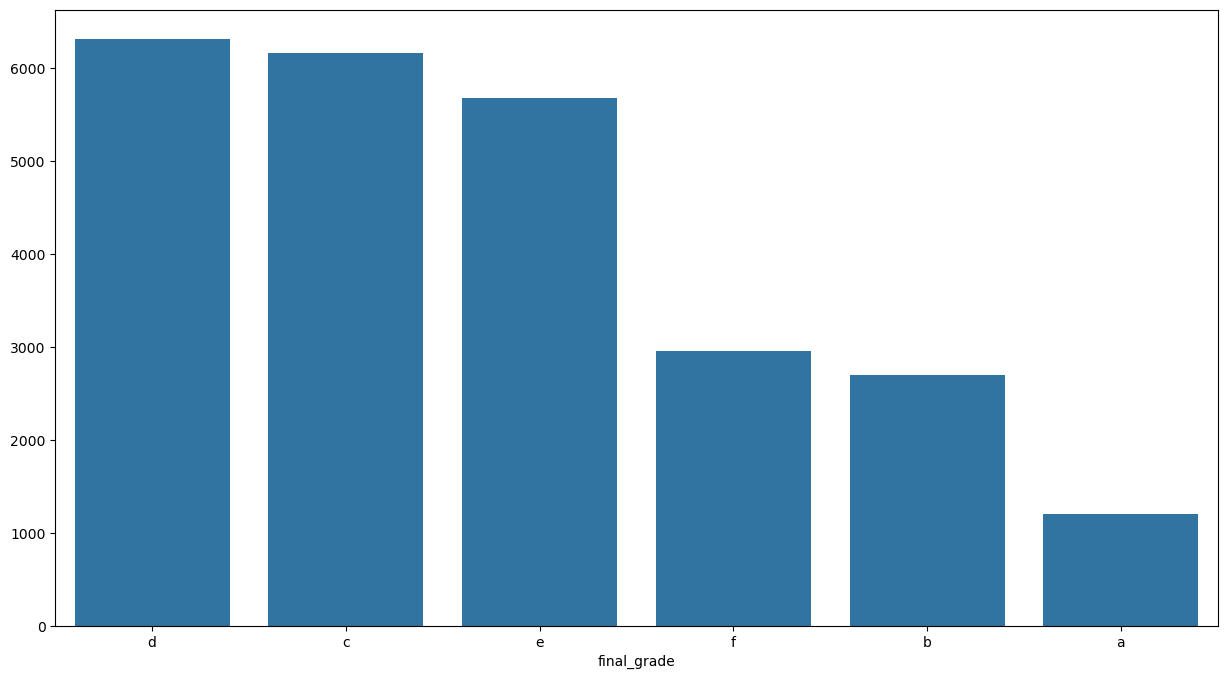

In [20]:
finalGradeCount=df['final_grade'].value_counts()
plt.figure(figsize=(15,8))
sns.barplot(x=finalGradeCount.index,y=finalGradeCount.values)

<Axes: ylabel='attendance_percentage'>

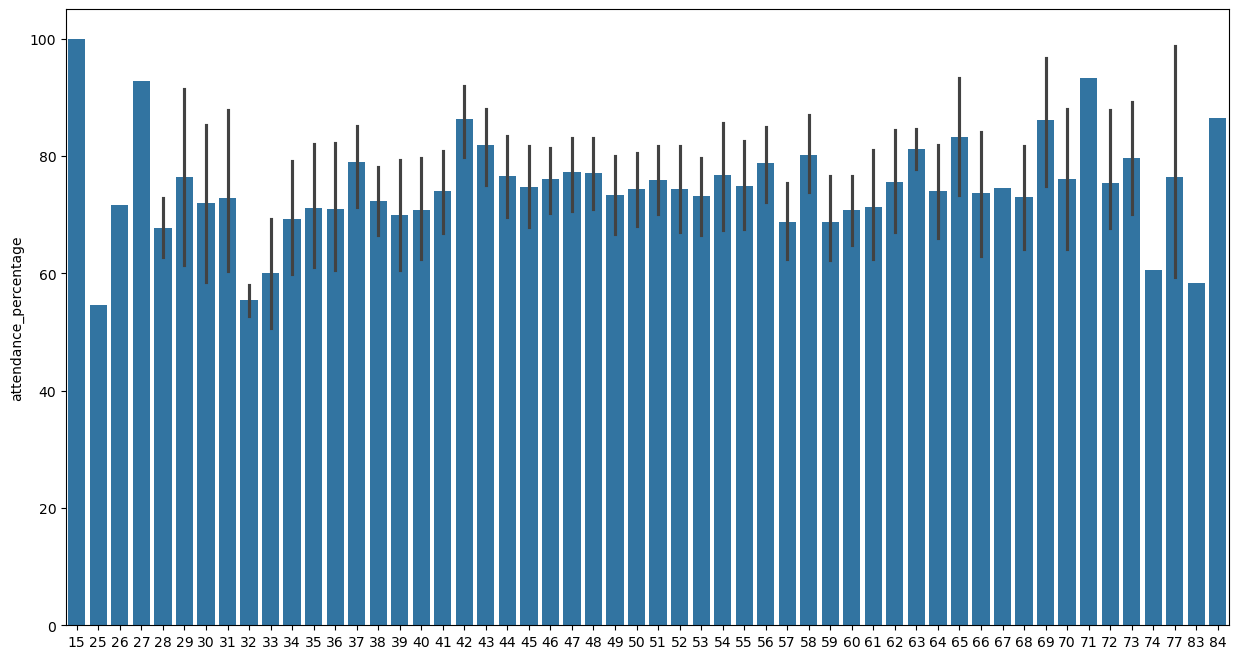

In [21]:
attendancePercentageCount=df['attendance_percentage'].value_counts()
plt.figure(figsize=(15,8))
sns.barplot(x=attendancePercentageCount.values,y=attendancePercentageCount.index)

<Axes: xlabel='age', ylabel='count'>

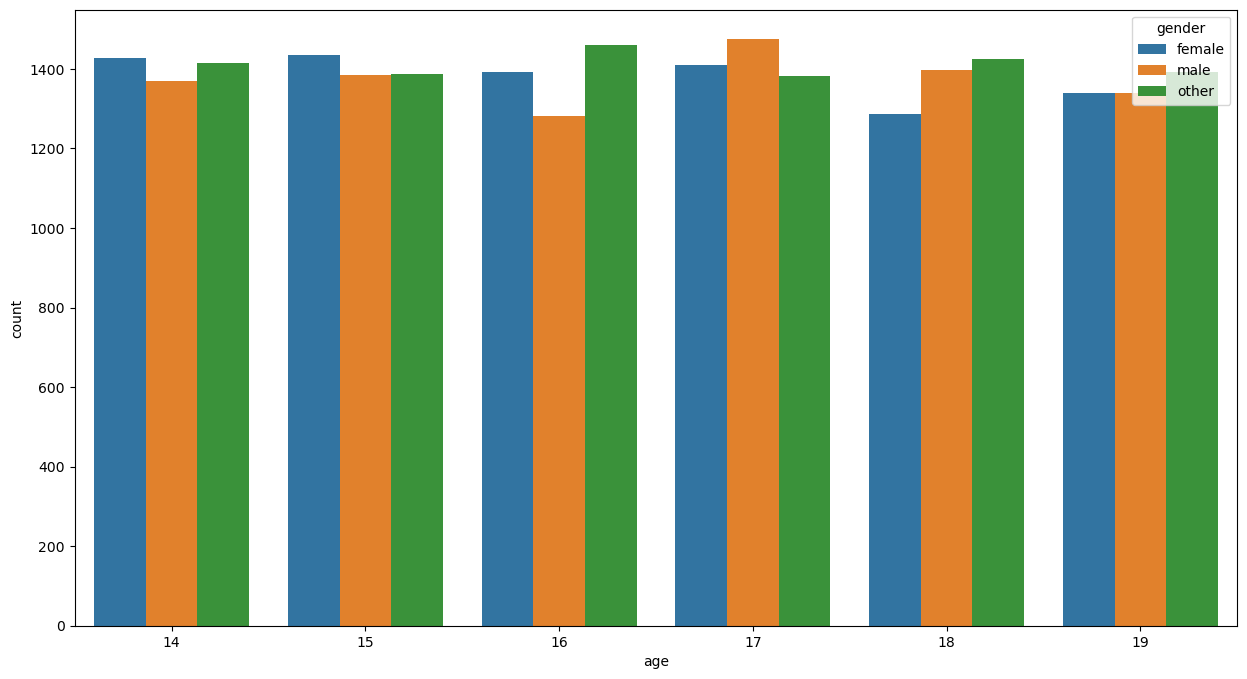

In [22]:
data=df.groupby(['age','gender']).size().reset_index(name="count")
plt.figure(figsize=(15,8))
sns.barplot(data=data,x='age',y='count',hue='gender')


<Axes: xlabel='travel_time'>

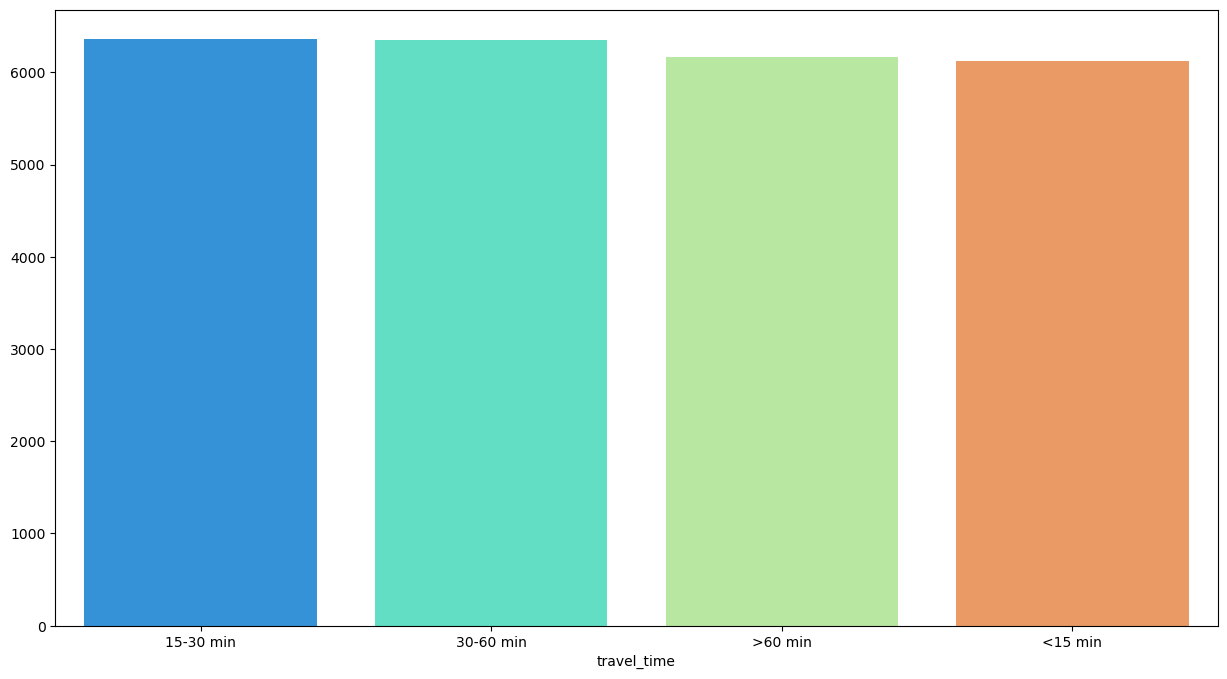

In [23]:
travelTimeCount=df['travel_time'].value_counts()
plt.figure(figsize=(15,8))
sns.barplot(x=travelTimeCount.index,y=travelTimeCount.values,palette='rainbow')